In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [5]:
# 1. Load the data
shooting = pd.read_csv('shooting.csv')
advanced_metrics = pd.read_csv('advanced_metrics.csv')

# 2. Merge the data on 'Player'
# We are no longer filtering by 'Player Current Team' == 'Huskies'
merged_df = pd.merge(shooting, advanced_metrics, how='inner', on='Player')

# 3. Clean and preprocess the data
# Replace string 'N/A' with np.nan, then fill all NaNs with 0
merged_df = merged_df.replace('N/A', np.nan)
merged_df = merged_df.fillna(0)

# Define which columns need to be stripped of '%' and converted to float
percent_cols = ['SOT%', 'ES OZ F/O Win %', 'XGF %']
for col in percent_cols:
    if col in merged_df.columns:
        # Convert to string, remove '%', convert to float, and normalize
        merged_df[col] = merged_df[col].astype(str).str.replace('%', '', regex=False)
        merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce').fillna(0) / 100

# Identify non-numeric columns to exclude from our clustering features
cols_to_drop = ['Player', 'Player Current Team', 'Player Total Time on Ice (Minutes)', 'Position', 'Team']
feature_cols = [col for col in merged_df.columns if col not in cols_to_drop]

# Ensure all feature columns are strictly numeric
for col in feature_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce').fillna(0)

# Filter out players with very small sample sizes to reduce noise (Optional but recommended)
merged_df = merged_df[merged_df['Player Total Games Played'] >= 10].reset_index(drop=True)

# 4. Standardize the data for clustering
X = merged_df[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

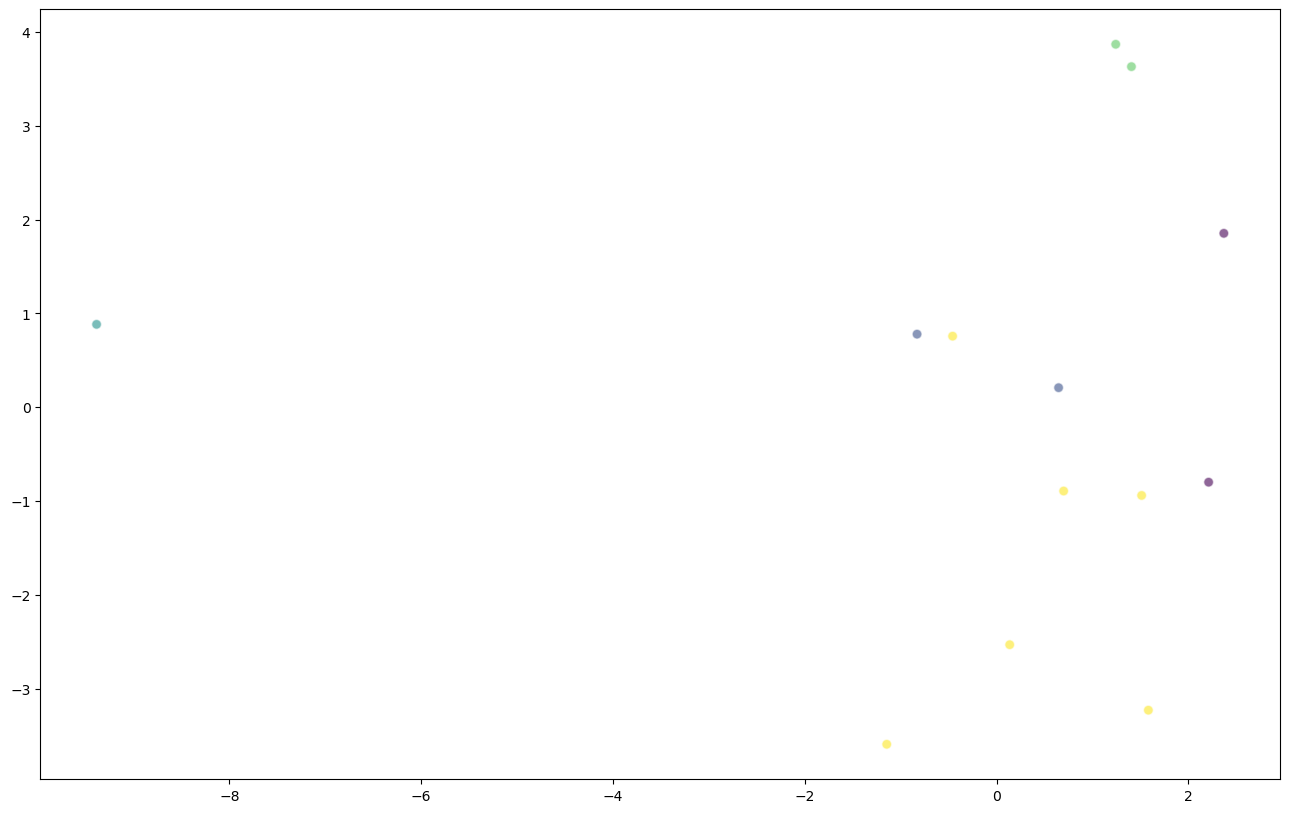

In [6]:
# 5. Train the Clustering Model (K-Means)
# We'll group players into 5 clusters based on their statistical profiles
kmeans = KMeans(n_clusters=5, random_state=42)
merged_df['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Dimensionality Reduction for 2D Visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)
merged_df['PCA1'] = pca_components[:, 0]
merged_df['PCA2'] = pca_components[:, 1]

# 7. Visualization
plt.figure(figsize=(16, 10))

# Plot all clusters
scatter = plt.scatter(
    merged_df['PCA1'], 
    merged_df['PCA2'], 
    c=merged_df['Cluster'], 
    cmap='viridis', 
    alpha=0.6, 
    s=50,
    edgecolors='w'
)

/var/folders/g1/5jyzgjs54vj6npmtcwwyq7cr0000gn/T/ipykernel_84884/3016678838.py:1: UserWarning: Adding colorbar to a different Figure <Figure size 1600x1000 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label='Player Cluster')


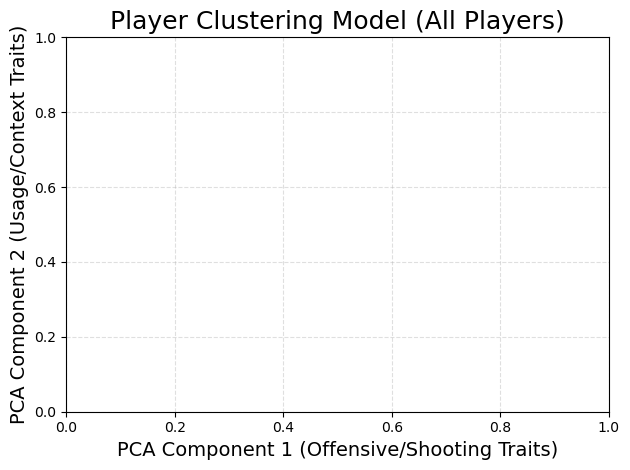

,Player,Player Current Team,Cluster,Player Total Games Played


In [7]:
plt.colorbar(scatter, label='Player Cluster')
plt.title('Player Clustering Model (All Players)', fontsize=18)
plt.xlabel('PCA Component 1 (Offensive/Shooting Traits)', fontsize=14)
plt.ylabel('PCA Component 2 (Usage/Context Traits)', fontsize=14)

# 8. Highlight Specific Players
players_to_highlight = ['Gavin McKenna', 'Porter Martone', 'James Hagens', 'Wyttenbach']

# Loop through and find the players using a case-insensitive search
for player_name in players_to_highlight:
    # Find matching players in the dataframe
    match = merged_df[merged_df['Player'].str.contains(player_name, case=False, na=False)]
    
    for idx, row in match.iterrows():
        # Plot a large red star for the targeted players
        plt.scatter(row['PCA1'], row['PCA2'], color='red', edgecolor='black', s=400, marker='*', zorder=5)
        
        # Add a text label next to the star
        plt.annotate(
            row['Player'], 
            (row['PCA1'], row['PCA2']),
            xytext=(10, 10), 
            textcoords='offset points',
            fontsize=12,
            fontweight='bold',
            color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", alpha=0.8),
            zorder=6
        )

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Display the clustered info of the highlighted players for a textual breakdown
highlight_mask = merged_df['Player'].str.contains('|'.join(players_to_highlight), case=False, na=False)
merged_df[highlight_mask][['Player', 'Player Current Team', 'Cluster', 'Player Total Games Played']]


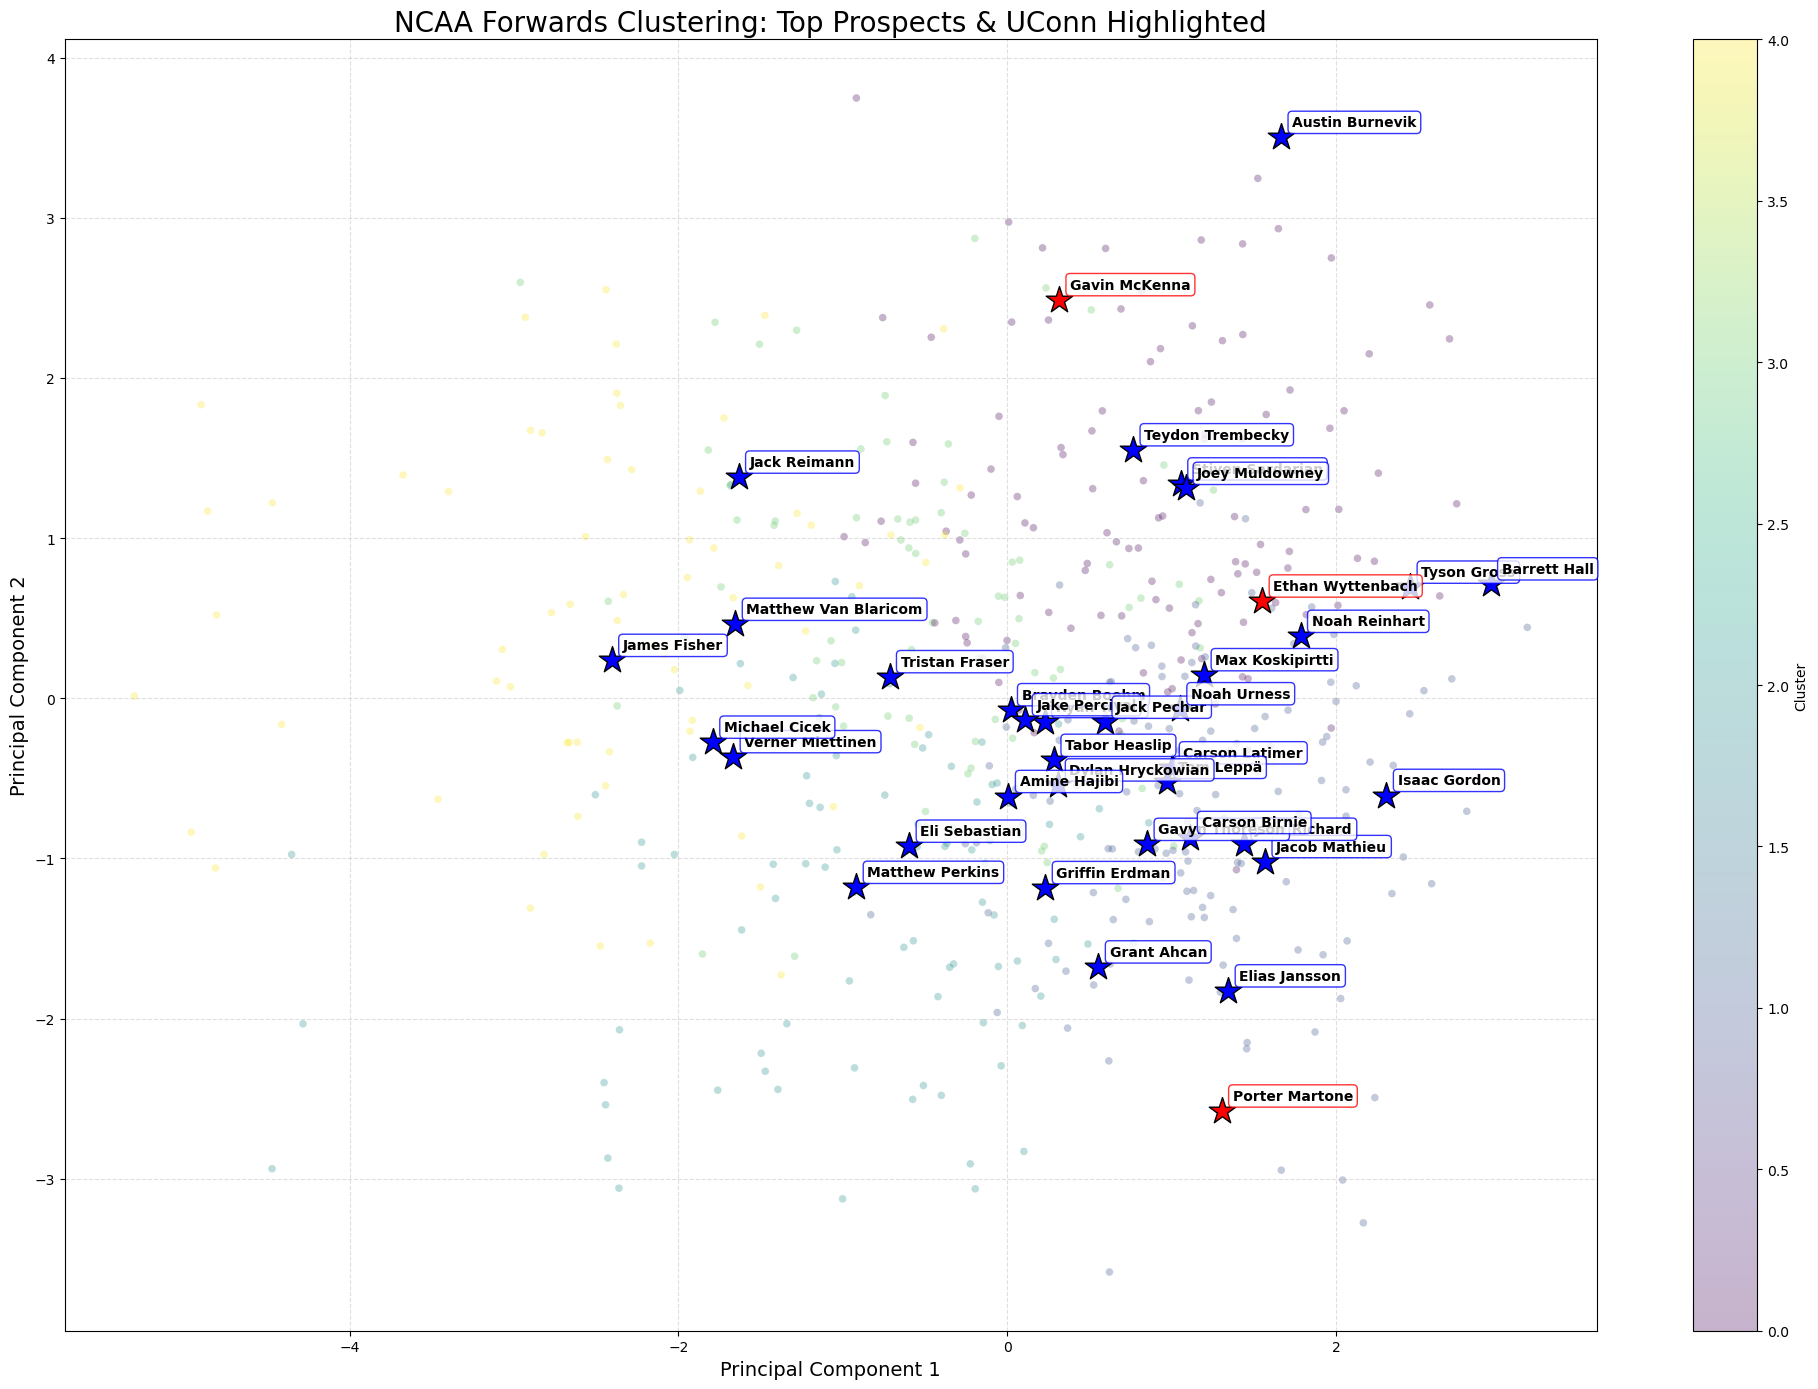

--- Context for Principal Components ---

Principal Component 1 (X-Axis) is primarily driven by:
Positive drivers (Moving Right):
  + Player Total Time on Ice (0.55)
  + Player Total Games Played (0.49)
  + innerSlot-shotsTotalPercentage (0.27)
Negative drivers (Moving Left):
  - westPoint-shotsTotalPercentage (-0.33)
  - eastPoint-shotsTotalPercentage (-0.33)
  - beyondBlueLine-shotsTotalPercentage (-0.28)

Principal Component 2 (Y-Axis) is primarily driven by:
Positive drivers (Moving Up):
  + eastOuterSlot-shotsTotalPercentage (0.50)
  + centerPoint-shotsTotalPercentage (0.38)
  + eastPoint-shotsTotalPercentage (0.31)
Negative drivers (Moving Down):
  - outsideNorthWest-shotsTotalPercentage (-0.50)
  - innerSlot-shotsTotalPercentage (-0.38)
  - westPoint-shotsTotalPercentage (-0.23)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load the data
df = pd.read_csv('shooting.csv')

# 2. Clean the data
# Replace 'N/A' strings with actual NaN values, then drop any rows with missing data
df = df.replace('N/A', np.nan)

# Clean percentage columns if they exist as strings
for col in df.columns:
    if df[col].dtype == object and df[col].astype(str).str.contains('%').any():
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce') / 100

df = df.dropna().reset_index(drop=True)

# Identify non-numeric identifier columns to exclude from our features
cols_to_drop = ['Player', 'Player Current Team', 'Player Total Time on Ice (Minutes)', 'Position', 'Team']
feature_cols = [col for col in df.columns if col not in cols_to_drop and pd.api.types.is_numeric_dtype(df[col])]

# 3. Standardize the data
X = df[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Clustering Model (K-Means)
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Dimensionality Reduction (PCA)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)
df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

# 6. Visualization
plt.figure(figsize=(20, 14))

# Plot all players in the background
scatter = plt.scatter(
    df['PCA1'], 
    df['PCA2'], 
    c=df['Cluster'], 
    cmap='viridis', 
    alpha=0.3, 
    s=30,
    edgecolors='none'
)

plt.colorbar(scatter, label='Cluster')

# Define conditions for highlighting
players_to_highlight = ['Gavin McKenna', 'Porter Martone', 'James Hagens', 'Wyttenbach']
is_selected_player = df['Player'].str.contains('|'.join(players_to_highlight), case=False, na=False)

# Assuming UConn players are labeled as 'Huskies' or 'UConn' in the team column
is_uconn_player = df['Player Current Team'].str.contains('Huskies|UConn', case=False, na=False)

# Combine the masks
highlight_mask = is_selected_player | is_uconn_player
highlighted_df = df[highlight_mask]

# Plot the highlighted players and their names
for idx, row in highlighted_df.iterrows():
    # Differentiate colors for visual clarity: Red for specific prospects, Blue for UConn
    is_prospect = any(h_name.lower() in row['Player'].lower() for h_name in players_to_highlight)
    marker_color = 'red' if is_prospect else 'blue'
    
    plt.scatter(row['PCA1'], row['PCA2'], color=marker_color, edgecolor='black', s=400, marker='*', zorder=10)
    plt.annotate(
        row['Player'], 
        (row['PCA1'], row['PCA2']),
        xytext=(8, 8), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='black',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=marker_color, alpha=0.8),
        zorder=11
    )

plt.title('NCAA Forwards Clustering: Top Prospects & UConn Highlighted', fontsize=20)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 7. Principal Component Context Analysis
print("--- Context for Principal Components ---")
# Get the components (weights)
components = pd.DataFrame(pca.components_, columns=feature_cols, index=['PCA1', 'PCA2'])

# Get top 3 positive and negative contributing features for PCA1
pca1_top_pos = components.loc['PCA1'].nlargest(3)
pca1_top_neg = components.loc['PCA1'].nsmallest(3)

print("\nPrincipal Component 1 (X-Axis) is primarily driven by:")
print("Positive drivers (Moving Right):")
for feat, val in pca1_top_pos.items(): print(f"  + {feat} ({val:.2f})")
print("Negative drivers (Moving Left):")
for feat, val in pca1_top_neg.items(): print(f"  - {feat} ({val:.2f})")

# Get top 3 positive and negative contributing features for PCA2
pca2_top_pos = components.loc['PCA2'].nlargest(3)
pca2_top_neg = components.loc['PCA2'].nsmallest(3)

print("\nPrincipal Component 2 (Y-Axis) is primarily driven by:")
print("Positive drivers (Moving Up):")
for feat, val in pca2_top_pos.items(): print(f"  + {feat} ({val:.2f})")
print("Negative drivers (Moving Down):")
for feat, val in pca2_top_neg.items(): print(f"  - {feat} ({val:.2f})")